### CA2 Part B (Reinforcement Learning) 
#### Liew Zheng Hao (p2510848), Ephraim, Han Qian

### Objective: 
To create a model that should exert some appropriate torque on the pendulum to balance it, suitably modified from deep Q-network (DQN) architecture.

In [45]:
### Imports 
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
import gym

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
# import seaborn as sns
# import plotly.express as px 

import random
from collections import deque
import os
import time

In [46]:
# Limit to only use CPU
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

##### Define class for Deep-Q Learning and the neural network (from lab)

In [47]:
class DQN:
    def __init__(self,
                 InputShape = 4, # How many quantities for your state space your agent is observing.
                 NActions = 2, # Number of actions you can take in for your agent.
                 Gamma = 1, # Discount factor. You can change this here.
                 ReplayMemorySize = 10000, # You can change the size of your memory buffer.
                 MinReplayMemory = 1000, # Minimum number of data points in your memory buffer, before training.
                 UpdateTargetEveryThisEpisodes = 1, # How frequently your target network updates the main network.
                 IntermediateSize = 64, # This is the related to the neural network for predicting Q-values.
                 BatchSize = 32):
        
        # Hyperparameters. #
        
        self.InputShape = InputShape
        self.NActions = NActions
        self.Gamma = Gamma
        self.ReplayMemorySize = ReplayMemorySize
        self.MinReplayMemory = MinReplayMemory
        self.UpdateTargetEveryThisEpisodes = UpdateTargetEveryThisEpisodes
        self.IntermediateSize = IntermediateSize
        self.BatchSize = BatchSize
        
        # Main model. #
        
        self.Main = self.CreateModel('Main')
        self.Optimiser = Adam()
        
        # Target model. #
        
        self.Target = self.CreateModel('Target')
        self.Target.set_weights(self.Main.get_weights())
        
        # Replay memory. #
        
        self.ReplayMemory = deque(maxlen = ReplayMemorySize)
        
        # Target network update counter. #
        
        self.TargetUpdateCounter = 0

    # [Neural Network architecture was change, from 2 hidden layers in the lab to 3 hidden layers here.]
    def CreateModel(self, Type): # If you want, you can change the neural network architecture here.
        inputs = Input(shape = (self.InputShape), name = 'Input')
        x = Dense(self.IntermediateSize, activation = 'relu', name = '1stHiddenLayer')(inputs)
        x = Dense(self.IntermediateSize, activation = 'relu', name = '2ndHiddenLayer')(x)
        x = Dense(self.IntermediateSize, activation = 'relu', name = '3ndHiddenLayer')(x)
        outputs = Dense(self.NActions, activation = 'linear', name = 'Output')(x)
        
        NN = Model(inputs, outputs, name = f'{Type}')
        NN.summary()
        
        return NN
    
    def UpdateReplayMemory(self, Information): # Information = (S, A, R, SNext, Done)
        self.ReplayMemory.append(Information)

    def Train(self, EndOfEpisode):
        
        # Only train if replay memory has enough data. #
        
        if len(self.ReplayMemory) < self.MinReplayMemory:
            print(f'DID NOT TRAIN..., replay memory = {len(self.ReplayMemory)}')
            return
        
        # Get batch of data for training. #
        
        TrainingData = random.sample(self.ReplayMemory, self.BatchSize)
        
        # Get states from training data, then get corresponding Q values. #
        
        ListOfS = np.array([element[0] for element in TrainingData])
        ListOfQ = np.array(self.Main(ListOfS))
        
        # Get future states from training data, then get corresponding Q values. #
        
        ListOfSNext = np.array([element[3] for element in TrainingData])
        ListOfQNext = self.Target(ListOfSNext)
        
        # Build actual training data for neural network. #
        
        X = []
        Y = []
        for index, (S, A, R, SNext, Done) in enumerate(TrainingData):
            if not Done:
                MaxQNext = np.max(ListOfQNext[index])
                QNext = R + self.Gamma * MaxQNext
            else:
                QNext = R
            Q = ListOfQ[index]
            Q[A] = QNext
        
            X.append(S)
            Y.append(Q)
        
        # Train model using tf.GradientTape(), defined below.
    
        self.GTfit(X, Y)
                
        # Update target network every episode. #
        
        if EndOfEpisode:
            self.TargetUpdateCounter += 1
        
        # Update target if counter is full. #
        
        if self.TargetUpdateCounter >= self.UpdateTargetEveryThisEpisodes:
            self.Target.set_weights(self.Main.get_weights())
            self.TargetUpdateCounter = 0
    
    # This is the tf.GradientTape() which significantly speeds up training of neural networks.
    
    @tf.function
    def GTfit(self, X, Y):
        
        # Train the neural network with this batch of data. #
        
        with tf.GradientTape() as tape:
            Predictions = self.Main(tf.convert_to_tensor(X), training = True)
            Loss = tf.math.reduce_mean(tf.math.square(tf.convert_to_tensor(Y) - Predictions))
        Grad = tape.gradient(Loss, self.Main.trainable_variables)
        self.Optimiser.apply_gradients(zip(Grad, self.Main.trainable_variables))

In [48]:
##### Set up base vars

In [49]:
pendulum = 'Pendulum-v0'
gravity = 9.81
### g to vary, 9.81 (base), 0 (free fall), -10 (antigravity), and 15 (supergravity), in that order.

IntermediateSize = 64
ShowEvery = 20 # Render the animation every 20 episodes. (changed from 10 from lab)
InputShape = (3, ) # The number of quantities in your state space. (3 for pendulum for the 3 vars: cos(theta), sin(theta) and angular velocity)

In [50]:
action_space = np.linspace(-2.0, 2.0, 5) 
NActions = len(action_space) 
# Action Space: Since the normal action space is continuous, in order to use DQN, we must discretise the action space into a finite set of actions.
# This is because DQN trades the traditional Q-table for a neural network, which requires a fixed number of output nodes to compute argmax. 

epsilon = 0.01 # Epsilon: the probability that the agent ignores its prior knowledge and takes a random action. 
# This can result in the agent finding different ways to solve the problem, but the agent could make a bad decision that accumulates more penalty points.

In [51]:
def OneEpisode(episode, Epsilon, agent):
    env = gym.make(f'{pendulum}', g=gravity)
    S = env.reset()
    ListOfRewards = []
    Done = False
    while not Done:
        Q = agent.Main(S.reshape(-1, S.shape[0]))
       
        if np.random.rand() < Epsilon:
            A = np.random.randint(0, NActions) 
        else:
            A = np.argmax(Q)                   
            
        if not episode % ShowEvery and len(agent.ReplayMemory) >= agent.MinReplayMemory:
            env.render()
            
        torque_action = [action_space[A]]
        
        SNext, R, Done, Info = env.step(torque_action)
        agent.UpdateReplayMemory((S, A, R, SNext, Done))
        agent.Train(Done)
        ListOfRewards.append(R)
        
        if Done:
            print(f'Finished! Return: {np.sum(ListOfRewards):.2f}')
            env.close()
            return np.sum(ListOfRewards)
        S = SNext

In [52]:
results = {}

In [53]:
start_time = time.time()
num_episodes = 200 

returns = []
agent = DQN(InputShape = InputShape, NActions = NActions)

for episode in range(num_episodes):
    print(f'Episode {episode}')
    episode_return = OneEpisode(episode, epsilon, agent)
    returns.append(episode_return)

time_taken = time.time() - start_time
print(f'Total time taken: {time_taken:.2f} seconds.')

Model: "Main"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 3)]               0         
                                                                 
 1stHiddenLayer (Dense)      (None, 64)                256       
                                                                 
 2ndHiddenLayer (Dense)      (None, 64)                4160      
                                                                 
 3ndHiddenLayer (Dense)      (None, 64)                4160      
                                                                 
 Output (Dense)              (None, 5)                 325       
                                                                 
Total params: 8901 (34.77 KB)
Trainable params: 8901 (34.77 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "Target"
____________

In [54]:
results["epsilon_001"] = {
    'returns': returns,
    'mean_full': np.mean(returns),
    'std_full': np.std(returns),
    'mean_end': np.mean(returns[-50:]),
    'std_end': np.std(returns[-50:]),
    'rolling_avg': pd.Series(returns).rolling(window=10).mean()
}

stats_cols = ['mean_full', 'std_full', 'mean_end', 'std_end']
display(pd.DataFrame(results).T[stats_cols])

,mean_full,std_full,mean_end,std_end
epsilon_001,-253.509974,323.670728,-153.818233,120.510149


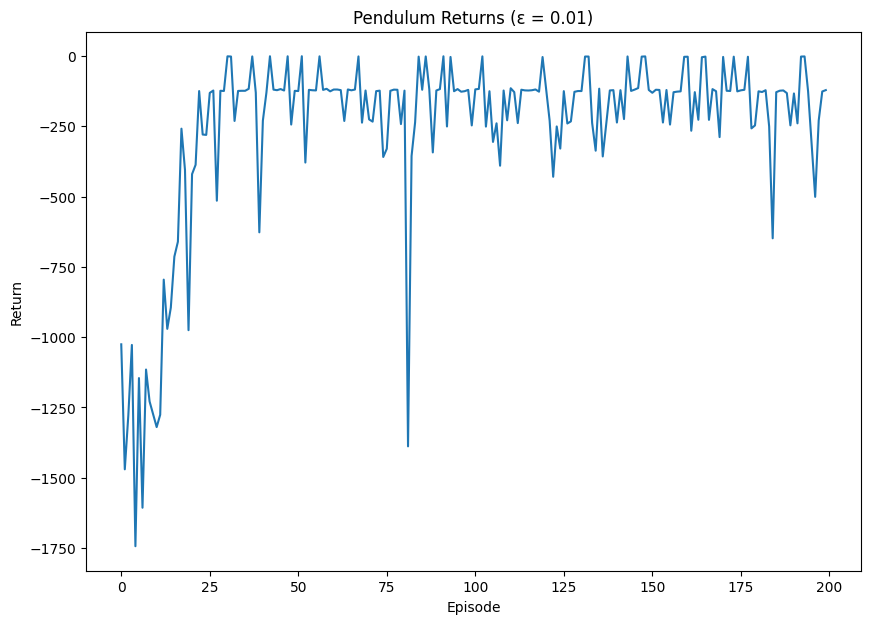

In [55]:
### Plot the graph of the scores over all episodes
returns = results["epsilon_001"]["returns"]

plt.figure(figsize=(10, 7))
plt.plot(returns, label="Returns")
plt.xlabel("Episode")
plt.ylabel("Return") 
plt.title("Pendulum Returns (ε = 0.01)")
plt.show()

### Experiment 1: Implement Epsilon-Greedy
Instead of setting a fixed value of epsilon, set it to a high value at the start, then decrease it as the episodes run. 
This is to encourage the agent to take more random actions at the start to learn more possible outcomes, then use that knowledge to better solve the problem.

In [56]:
### Experiment 1: Implement Epsilon-Greedy
startE = 0.99
endE = 0.01
decay = 0.97

epsilon = startE

In [57]:
start_time = time.time()
num_episodes = 200 

returns = []
agent = DQN(InputShape = InputShape, NActions = NActions)

for episode in range(num_episodes):
    print(f'Episode {episode} | Epsilon {epsilon:.3f}')
    episode_return = OneEpisode(episode, epsilon, agent)
    returns.append(episode_return)

    if len(agent.ReplayMemory) >= agent.MinReplayMemory:
        epsilon = max(endE, epsilon * decay)
        
time_taken = time.time() - start_time

print(f'Total time taken: {time_taken:.2f} seconds.')

Model: "Main"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 3)]               0         
                                                                 
 1stHiddenLayer (Dense)      (None, 64)                256       
                                                                 
 2ndHiddenLayer (Dense)      (None, 64)                4160      
                                                                 
 3ndHiddenLayer (Dense)      (None, 64)                4160      
                                                                 
 Output (Dense)              (None, 5)                 325       
                                                                 
Total params: 8901 (34.77 KB)
Trainable params: 8901 (34.77 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "Target"
____________

In [61]:
results["epsilon_greedy_150"] = {
    'returns': returns,
    'mean_full': np.mean(returns),
    'std_full': np.std(returns),
    'mean_end': np.mean(returns[-50:]),
    'std_end': np.std(returns[-50:]),
    'rolling_avg': pd.Series(returns).rolling(window=10).mean()
}

stats_cols = ['mean_full', 'std_full', 'mean_end', 'std_end']
display(pd.DataFrame(results).T[stats_cols].iloc[[-1]])
rolling_avg = results["epsilon_greedy_150"]["rolling_avg"]
print(f'Mean Rolling Avg: {rolling_avg.mean()}')

,mean_full,std_full,mean_end,std_end
epsilon_greedy_150,-307.858877,343.919799,-175.213388,94.472534


Mean Rolling Avg: -288.0955653101037


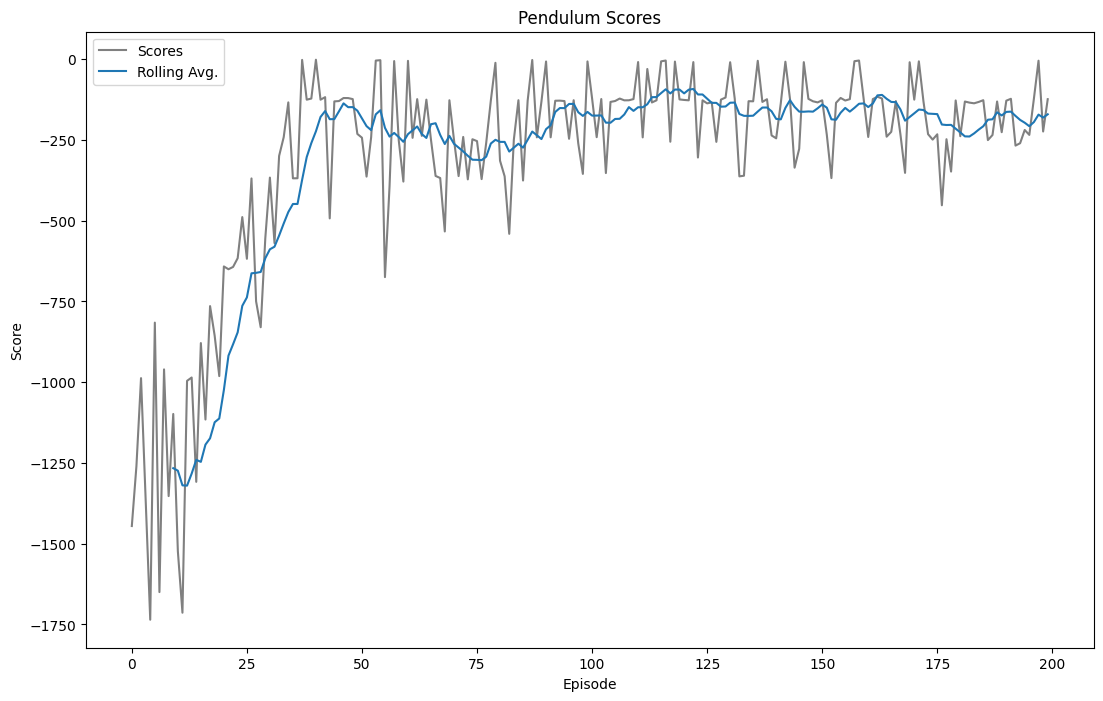

In [60]:
returns = results["epsilon_greedy_150"]["returns"]

plt.figure(figsize=(13, 8))
plt.plot(returns, color='gray', label="Scores")
plt.plot(rolling_avg, label="Rolling Avg.")
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('Pendulum Scores')
plt.legend()
plt.show()

In [ ]:
summary = pd.Dataframe(results).T([stats_cols])
display(summary)